In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from lib.readwav import readwav
#from lib.functions import get_average_spectrum
import ipywidgets as widgets
from numpy.lib.stride_tricks import sliding_window_view
from scipy import signal
from scipy.fft import rfft, rfftfreq

In [3]:
%matplotlib widget
plt.close('all')

In [4]:
# trova i file disponibili
available_files = [f for f in os.listdir('Data_organ') if f.endswith('.wav')]

available_files = sorted(available_files, key=lambda x: int(x.split("_")[1].split(".")[0]), reverse=False) # ordina i file in base al numero dopo "organ_"

available_files =  available_files

print("File disponibili:")
for f in available_files:
    print(f)

File disponibili:
note_1.wav
note_2.wav
note_3.wav
note_4.wav
note_5.wav
note_6.wav
note_7.wav
note_8.wav
note_9.wav
note_10.wav
note_11.wav
note_12.wav
note_13.wav
note_14.wav
note_15.wav
note_16.wav
note_17.wav
note_18.wav
note_19.wav
note_20.wav
note_21.wav
note_22.wav
note_23.wav
note_24.wav
note_25.wav
note_26.wav
note_27.wav
note_28.wav
note_29.wav
note_30.wav
note_31.wav
note_32.wav
note_33.wav
note_34.wav
note_35.wav
note_36.wav
note_37.wav
note_38.wav
note_39.wav
note_40.wav
note_41.wav
note_42.wav
note_43.wav
note_44.wav
note_45.wav
note_46.wav
note_47.wav
note_48.wav
note_49.wav
note_50.wav
note_51.wav
note_52.wav
note_53.wav
note_54.wav
note_55.wav
note_56.wav
note_57.wav
note_58.wav
note_59.wav
note_60.wav
note_61.wav
note_62.wav
note_63.wav
note_64.wav
note_65.wav
note_66.wav
note_67.wav
note_68.wav
note_69.wav
note_70.wav
note_71.wav
note_72.wav
note_73.wav
note_74.wav
note_75.wav
note_76.wav
note_77.wav
note_78.wav
note_79.wav
note_80.wav
note_81.wav
note_82.wav
note_83

In [5]:
avg_spectra = {}

for i, filename in enumerate(available_files):

    print(f"Processing file {i+1}/{len(available_files)}: {filename}")

    rate, data = readwav(os.path.join('Data_organ', filename))
    note = data[:,0]
    
    spect_r = rfft(note) 

    freq_r = rfftfreq(len(note), d=1/rate)

    rms_win_len = max(int(0.05 * rate), 1) 
    power = np.convolve(note**2, np.ones(rms_win_len) / rms_win_len, mode='same')
    rms = np.sqrt(np.maximum(power, 0))
    
    robust_max = np.percentile(rms, 95)
    threshold = robust_max * 0.5 # Define a threshold at 50% of the max stable RMS
    stable_indices = np.where(rms > threshold)[0]

    if stable_indices.size == 0:
        segment = note
    else:
        start, end = stable_indices[0], stable_indices[-1] 
        if end <= start:
            segment = note
        else:
            segment = note[start:end]

    width = (segment.shape[0] / rate) / 10 
    window_length = int(width * rate)
    sigma = window_length / 3


    gaussian_window = sp.signal.windows.gaussian(int(width * rate), std = sigma)

    freqs, avg_spectrum = sp.signal.welch(segment, fs = rate, window = gaussian_window, nperseg = window_length)

    avg_spectra[filename] = (freqs, avg_spectrum)



Processing file 1/280: note_1.wav
Processing file 2/280: note_2.wav
Processing file 3/280: note_3.wav
Processing file 4/280: note_4.wav
Processing file 5/280: note_5.wav
Processing file 6/280: note_6.wav
Processing file 7/280: note_7.wav
Processing file 8/280: note_8.wav
Processing file 9/280: note_9.wav
Processing file 10/280: note_10.wav
Processing file 11/280: note_11.wav
Processing file 12/280: note_12.wav
Processing file 13/280: note_13.wav
Processing file 14/280: note_14.wav
Processing file 15/280: note_15.wav
Processing file 16/280: note_16.wav
Processing file 17/280: note_17.wav
Processing file 18/280: note_18.wav
Processing file 19/280: note_19.wav
Processing file 20/280: note_20.wav
Processing file 21/280: note_21.wav
Processing file 22/280: note_22.wav
Processing file 23/280: note_23.wav
Processing file 24/280: note_24.wav
Processing file 25/280: note_25.wav
Processing file 26/280: note_26.wav
Processing file 27/280: note_27.wav
Processing file 28/280: note_28.wav
Processing

Dropdown(description='Spettro:', options=('note_1.wav', 'note_2.wav', 'note_3.wav', 'note_4.wav', 'note_5.wav'…

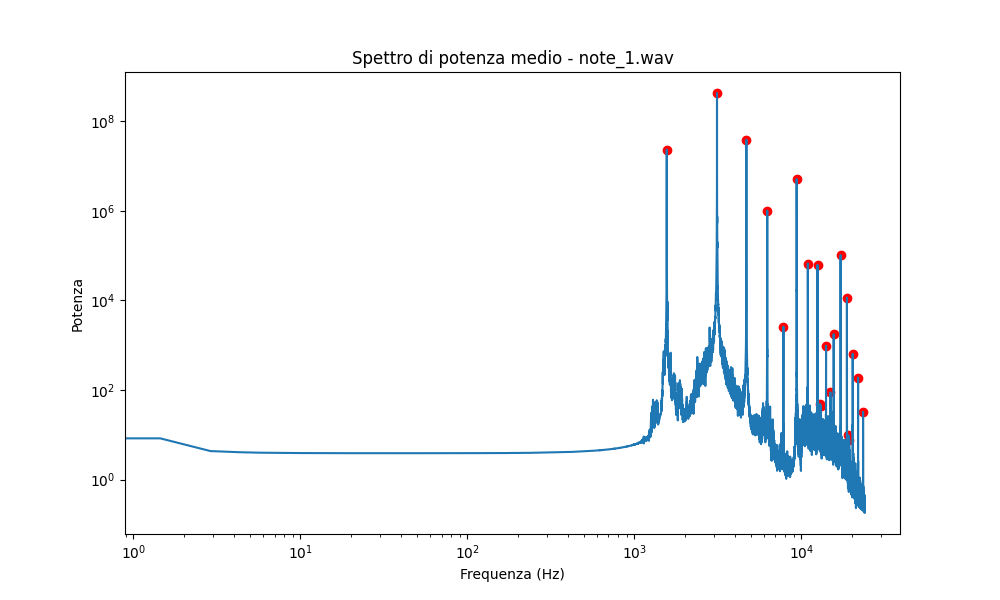

In [6]:
spectrum_selector = widgets.Dropdown( # widget per selezionare quale spettro visualizzare
    options=list(avg_spectra.keys()),
    description='Spettro:',
    disabled=False,
)

fig, ax = plt.subplots()
fig.set_size_inches(10, 6)
canvas = fig.canvas

def update_plot(change):
    filename = change['new']
    freqs, avg_spectrum = avg_spectra[filename]

    peaks,_ = sp.signal.find_peaks(np.log10(avg_spectrum), prominence=1)

    ax.clear()
    ax.plot(freqs, avg_spectrum)

    plt.scatter(freqs[peaks], avg_spectrum[peaks], color='red', label='Picchi')

    ax.set_title(f"Spettro di potenza medio - {filename}")
    ax.set_xlabel("Frequenza (Hz)")
    ax.set_ylabel("Potenza")
    ax.set_xscale('log')
    ax.set_yscale('log')

spectrum_selector.observe(update_plot, names='value')
display(spectrum_selector)
update_plot({'new': spectrum_selector.value})

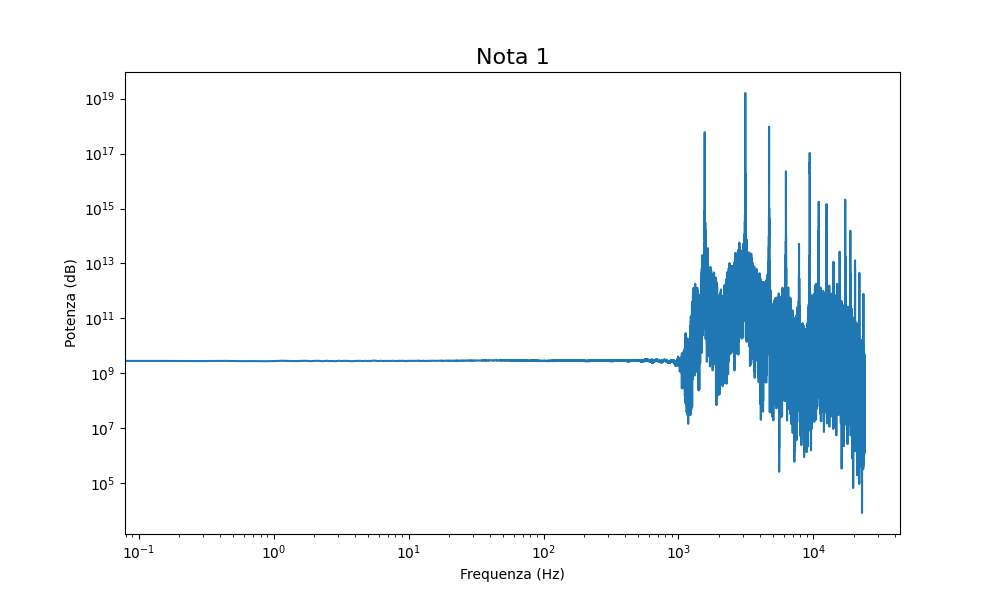

In [13]:
nota = "note_1.wav"

plt.figure(figsize=(10, 6))

# spettro della nota 1 non ripulito e senza taglio RMS
rate, data = readwav(os.path.join('Data_organ', nota))
note = data[:,0]
raw_spect_r = np.abs(rfft(note))**2 # normalizzazione per ottenere la potenza corretta
freq_r = rfftfreq(len(note), d=1/rate)

# spettro della nota 1 dopo il processo di segmentazione e finestratura
freqs, avg_spectrum = avg_spectra[nota]

delta_y = 0#raw_spect_r[0] - avg_spectrum[0] # spostamento verticale per allineare i due spettri al primo picco

plt.plot(freq_r, raw_spect_r - delta_y, label='Spettro prima del processo di segmentazione e finestratura')
#plt.plot(freqs, avg_spectrum, label='Spettro dopo il processo di segmentazione e finestratura')

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Frequenza (Hz)")
plt.ylabel("Potenza (dB)")
plt.title("Nota 1", fontsize=16)
#plt.legend()

plt.savefig("spettro_note_1_raw.pdf", format='pdf', bbox_inches='tight')

plt.show()
